# Статистический анализ данных

Вы аналитик популярного сервиса аренды самокатов GoFast. Вам передали данные о некоторых пользователях из нескольких городов, а также об их поездках. Проанализируйте данные и проверьте некоторые гипотезы, которые могут помочь бизнесу вырасти.
Чтобы совершать поездки по городу, пользователи сервиса GoFast пользуются мобильным приложением. Сервисом можно пользоваться:
* без подписки
  * абонентская плата отсутствует;
  * стоимость одной минуты поездки — 8 рублей;
  * стоимость старта (начала поездки) — 50 рублей;
* с подпиской Ultra
  * абонентская плата — 199 рублей в месяц;
  * стоимость одной минуты поездки — 6 рублей;
  * стоимость старта — бесплатно.

Импортируем все необходимые библиотеки для исследования:

In [1]:
import pandas as pd
import math
from math import sqrt
import matplotlib.pyplot as plt
from scipy import stats as st
from scipy.stats import binom, norm

### Шаг 1. Загрузка данных

#### Считаем CSV-файлы с данными с помощью библиотеки pandas и сохраним их в датафреймы.

Пути к файлам:
- `/datasets/users_go.csv`
- `/datasets/rides_go.csv`
- `/datasets/subscriptions_go.csv`

Данные из файлов сохраним в отдельные датафреймы.

In [2]:
users_go = pd.read_csv('/datasets/users_go.csv')
rides_go = pd.read_csv('/datasets/rides_go.csv')
subscriptions_go = pd.read_csv('/datasets/subscriptions_go.csv')

#### Выведем первые строки каждого набора данных. Изучим общую информацию о каждом датафрейме.

Выведем первые строки сохранённых датафреймов:

In [3]:
users_go.head()

,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra


In [4]:
rides_go.head()

,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28


In [5]:
subscriptions_go.head()

,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


Для лучшего понимания данных, хранящихся в датафреймах, выведем для каждого информацию о нём методом `.info()`:

In [6]:
users_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB


In [7]:
rides_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB


In [8]:
subscriptions_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes


После вызова метода `.info()` можно говорить о следующем:
- все названия столбцов имеют правильный вид записи (прописные буквы,  латинский алфавит, "змеевидная" запись(через нижнее подчеркивание))
- наличия пропусков в датафреймах не было выявлено; число ненулевых строк совпадает с общим числом строк каждого датафрейма
- в основном все типы данных правильно отображают данные в столбцах: целочисленные столбцы - например `user_id` - имеют тип данных `int64`, вещественные `duration` - `float64`, строковые `subscription_type` - `object`. Единственным выбивающимся из всех является тип данных `object` столбца `date`, который содержит в себе даты поездкок; исправим тип данных этого столбца в следующем шаге: **шаг 2.1**

### Шаг 2. Предобработка данных

#### Приведём столбец date к типу даты pandas.

С помощью метода **pd.to_datetime()** преобразуем столбец `'date'` датафрейма `rides_go` и запишем в него же преобразованные данные:

In [9]:
rides_go['date'] = pd.to_datetime(rides_go['date'], format='%Y-%m-%d')

Для проверки нашего преобразования снова выведем информацию о датафрейме методом `.info()`:

In [10]:
rides_go.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   user_id   18068 non-null  int64         
 1   distance  18068 non-null  float64       
 2   duration  18068 non-null  float64       
 3   date      18068 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 564.8 KB


Видно, что тип данных, который был ранее - `object`, преобразовался в `datetime64[ns]`, что говорит о правильности нашего преобразования.

#### Создадим новый столбец с номером месяца на основе столбца date.

Создадим новый столбец `'month_ride'`, с помощью метода **pd.to_datetime()** преобразуем столбец `'date'` и запишем полученный месяц в датафрейме `rides_go`:

In [11]:
rides_go['month_ride'] = pd.to_datetime(rides_go['date'], format='%Y-%m-%d').dt.month

Выведем датафрейм с новым столбцом:

In [12]:
rides_go.head()

,user_id,distance,duration,date,month_ride
0,1,4409.919140,25.599769,2021-01-01,1
1,1,2617.592153,15.816871,2021-01-18,1
2,1,754.159807,6.232113,2021-04-20,4
3,1,2694.783254,18.511000,2021-08-11,8
4,1,4028.687306,26.265803,2021-08-28,8


Столбец `'month_ride'` с номерами месяца был успешно добавлен в датафрейм `rides_go`;  данные корректно в него записываются и в нём отображаются.

#### Проверим наличие пропущенных значений и дубликатов в датафреймах. Обработаем их, если такие значения присутствуют.

Для проверки на пропуски воспользуемся методом `.isna()`. Применим его к каждому датафрейму.

In [13]:
users_go.isna().sum()

user_id              0
name                 0
age                  0
city                 0
subscription_type    0
dtype: int64

In [14]:
rides_go.isna().sum()

user_id       0
distance      0
duration      0
date          0
month_ride    0
dtype: int64

In [15]:
subscriptions_go.isna().sum()

subscription_type    0
minute_price         0
start_ride_price     0
subscription_fee     0
dtype: int64

Из результатов поиска видно, что *пропущенных значений* в датафреймах **нет** - это является очень хорошим показателем.

Теперь проверим на наличие дубликатов:

In [16]:
users_go.duplicated().sum()

31

In [17]:
rides_go.duplicated().sum()

0

In [18]:
subscriptions_go.duplicated().sum()

0

В результате наблюдаем, что дубликаты есть только в датафрейме `users_go`. Удалим эти дубликаты, так как их немного и скорее всего они были записаны в датафрейм случайно или из-за сбоя при выгрузке данных. 

С помощью метода `.drop_duplicates()` удалим дубликаты, параметру `keep` передадим значение `'first'` - оставим первые входящие в датафрейм строки с информацией, a параметру `subset` - `'user_id'`:

In [19]:
# Избавляемся от дубликатов в датафрейме users_go
users_go = users_go.drop_duplicates(subset=['user_id'], keep='first')

Проверим  датафрейм `users_go` ещё раз:

In [20]:
users_go.duplicated().sum()

0

Теперь после проверки данных на пропуски и избавления датафреймов от дубликатов, можно говорить, что они полностью готовы к дальнейшему исследовательскому анализу данных.

**Промежуточный вывод:**

В результате предобработки данных были выполнены следующие шаги:
- столбец `'date'` с типом данных `object` был приведён к типу даты pandas `datetime64[ns]`
- создан новый столбец `'month_ride'` с номером месяца на основе столбца `'date'`
- проверили наличие пропущенных значений и дубликатов в датафреймах
- обработали и удалили дубликаты в датафреймах 

### Шаг 3. Исследовательский анализ данных

**Опишем и визуализируем общую информацию о пользователях и поездках:**

#### Частота встречаемости городов;

Используя метод `.groupby()`, сгруппируем данные датафрейма `users_go` относительно городов и посчитаем их количество, запишем полученный результат в переменную `freq_city`:

In [21]:
freq_city = users_go.pivot_table(index='city', values='user_id', aggfunc='count').sort_values('user_id', ascending=False)

На основе имеющихся сгруппированных данных построим график столбчатой диаграммы и проанализируем его:

<AxesSubplot:title={'center':'Частота встречаемости городов'}, xlabel='Города', ylabel='Количество'>

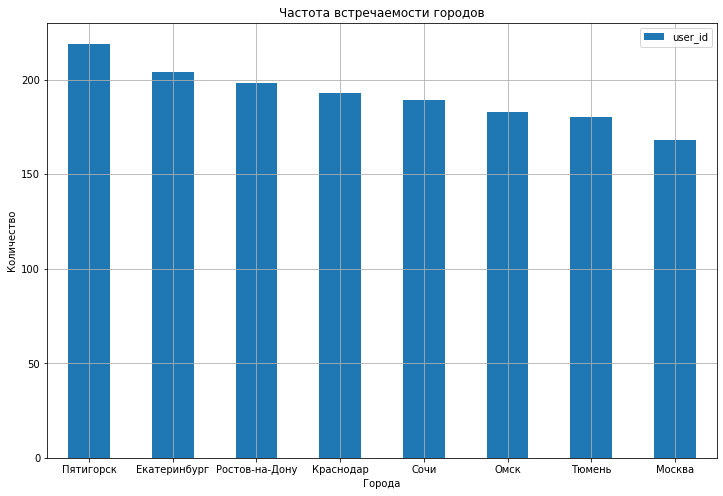

In [22]:
freq_city.plot(xlabel='Города', ylabel='Количество',
               title='Частота встречаемости городов', kind='bar', grid=True, figsize=(12, 8),rot=0)

Из полученной столбчатой диаграммы наблюдается следующее:
- Наиболее часто арендуют самокаты в таких городах как Пятигорск и Екатеринбург - более 200 раз
- Наименее часто арендуют самокаты в Москве, что странно, учитывая что это столица и центральная часть страны. Можно предположить, что из-за большого наличия конкурентов сервис GoFast не пользуется таким большим спросом.

#### Соотношение пользователей с подпиской и без подписки;

Построим сводную таблицу **.pivot_table()** с количеством типа подписки пользователя. В качестве аргумента `index` передадим столбец `'subscription_type'`, а `values` - `'user_id'`, на основе группируемых данных найдём их число. После выведем полученную таблицу.

In [23]:
sub_user = users_go.pivot_table(index='subscription_type', values='user_id', aggfunc='count')
sub_user

,user_id
subscription_type,
free,835
ultra,699


Переименнуем столбец `'user_id'` на `'count'`, а также добавим новый - `'ratio'`, в который запишем процентное соотношение данных столбца `'count'` к общему количеству пользователей.

In [24]:
sub_user.columns = ['count']
sub_user['ratio'] = round((sub_user['count']/len(users_go))*100, 2) 
sub_user

,count,ratio
subscription_type,,
free,835,54.43
ultra,699,45.57


Теперь построим столбчатую диаграмму, чтобы увидеть количество пользователей с подпиской и без подписки.

<AxesSubplot:title={'center':'Cоотношение пользователей с подпиской и без подписки'}, xlabel='Тип подписки', ylabel='Количество'>

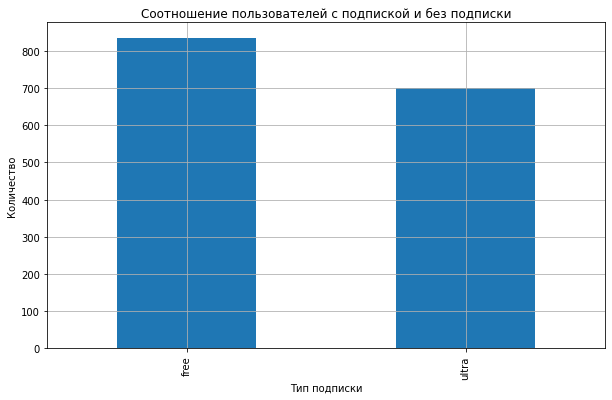

In [25]:
sub_user['count'].plot(xlabel='Тип подписки', ylabel='Количество',
               title='Cоотношение пользователей с подпиской и без подписки', kind='bar', grid=True, figsize=(10, 6))

Для большей наглядности построим круговую диаграмму, в которой покажем процентное соотношение пользователей с подпиской и без подписки к общему числу пользователей.

<AxesSubplot:title={'center':'Процентное соотношение пользователей с подпиской и без подписки к общему числу пользователей'}, ylabel='Тип подписки'>

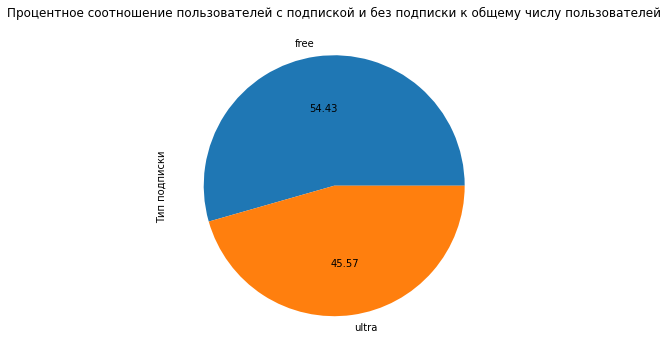

In [26]:
sub_user['ratio'].plot(ylabel='Тип подписки',
               title='Процентное соотношение пользователей с подпиской и без подписки к общему числу пользователей',
                       kind='pie', autopct='%.2f', grid=True, figsize=(10, 6))

Из данной диаграммы наглядно видно, что больше половины пользователей пользуются арендой самокатов без подписки. Из сводной таблицы мы можем точно указать, что это 54.43%, а остальные 45.57% - с подпиской.  

#### Возраст пользователей;

Построим гистограмму для наглядного определения возраста пользователей. Параметр `bins` установим равным `100`.

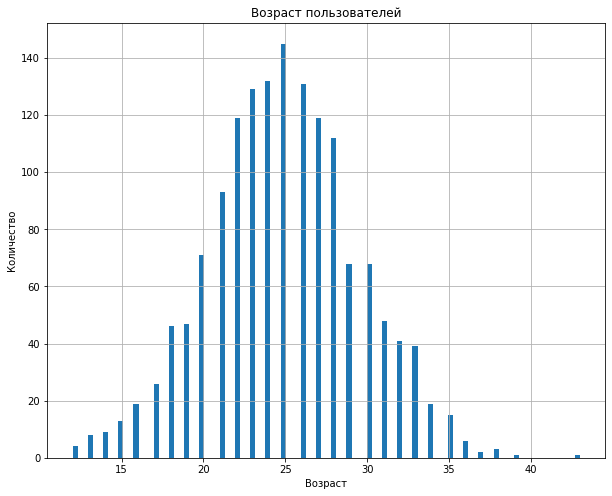

In [27]:
users_go_plot = users_go['age'].plot(title='Возраст пользователей', kind='hist', bins=100, grid=True, figsize=(10,8))
users_go_plot.set_xlabel('Возраст')
users_go_plot.set_ylabel('Количество')
plt.show()

Из построенной гистограммы можно заметить, что большая часть пользователей - от 20 до 30 лет - чаще всего являются пользователями аренды самокатов, пик приходится на 25 лет. Это можно обусловить тем, что часто молодые люди спешат и им легче и удобнее воспользоваться бытрой арендой самоката, чем ждать такси или городской транспорт.

#### Расстояние, которое пользователь преодолел за одну поездку;

Так как расстояние - величина вещественная, то удобнее построить гистограмму для наглядного ананлиза и для большей точности передать параметру `bins` большое значение, чтобы гистограмма была более точной - установим его равным `200`.

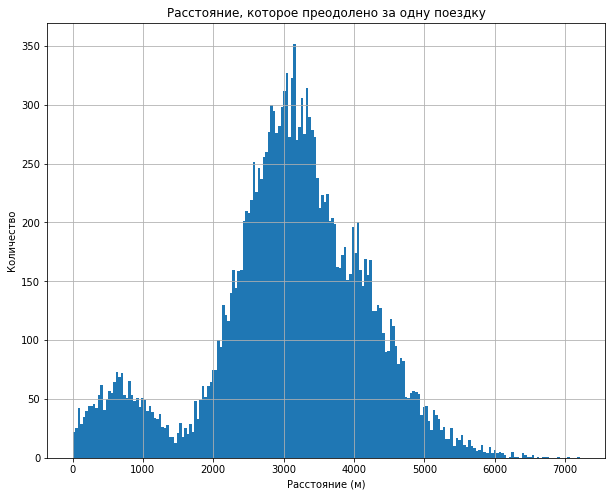

In [28]:
rides_go_plot = rides_go['distance'].plot(title='Расстояние, которое преодолено за одну поездку', kind='hist', bins=200, grid=True, figsize=(10,8))
rides_go_plot.set_xlabel('Расстояние (м)')
rides_go_plot.set_ylabel('Количество')
plt.show()

Из гистограммы видно, что присутствуют две горки: первая приходится на расстояние от 0 до 1000 метров, вторая - от 2500 до 3500 метров. Возростание первой горки скорее всего связано с тем, что пользователям нужно быстро куда-то добраться и им легче арендовать самокат, чем ждать общественный транспорт или такси. Про вторую горку можно сказать следующее: можно предположить, что пользователи брали самокат для поездки по парку или же они арендовывали его для того, чтобы добираться на работу или иное место назначения, в случае если есть пробки на дорогах. Также стоит отметить и то, что данный рост могут создавать пользователи с подпиской Ultra, так как их поминутный тариф дешевле на 2 рубля, старт поездки у них бесплатный, в связи с чем пользоваться могут чаще и дольше, в отличие от пользователей без подписки. 

#### Продолжительность поездок.

Продолжительность поездок тоже вещественная величина, поэтому построим гистограмму для наглядного ананлиза и для большей точности передать параметру `bins` большое значение, чтобы гистограмма была более точной - установим его равным `150`.

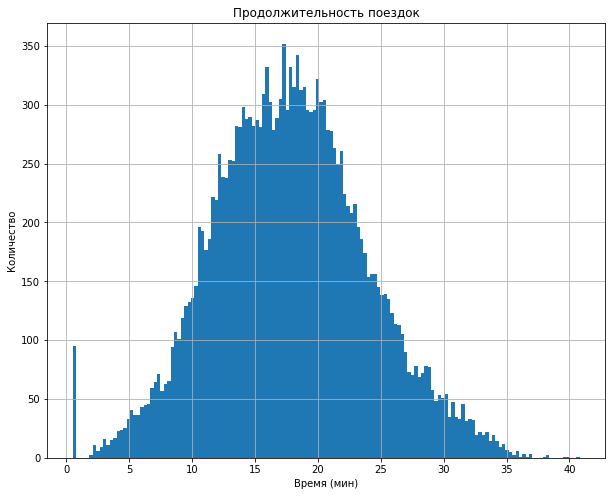

In [29]:
rides_go_time_plot = rides_go['duration'].plot(title='Продолжительность поездок', kind='hist', bins=150, grid=True, figsize=(10,8))
rides_go_time_plot.set_xlabel('Время (мин)')
rides_go_time_plot.set_ylabel('Количество')
plt.show()

Из гистограммы видно, что график похож на график нормального распределения - колокол. Наиболее частое время, на которое арендуют самокаты - от 11 до 24 минут. В начале графика можно увидеть выбивающийся скачок, можно предположить, что это связано с проверкой работоспособности самоката - можно ли приостановить поездку, чтобы не списывались деньги: к примеру остановка на светофоре или остановка с целью зайти в магазин - или нельзя.

**Промежуточный вывод:**

В результате исследовательского анализа были получены следующие результаты:
- Наиболее часто арендуют самокаты в городе Пятигорск и Екатеринбург, наименее часто - в Москве. Можно предположить, что это связано с большим наличием конкурентов в столице страны.
- Больше половины пользователей (54.43%) не пользуются подпиской при аренде самокатов. С подпиской только 45.57% пользователей. 
- Молодые люди от 20 до 30 лет чаще всего являются пользователями аренды самокатов, наиболее часто - пользователи 25 лет.
- Расстояние, которое пользователь преодолел за одну поездку, чаще либо до 1 километра, либо от 2,5 до 3,5 км.
- Наиболее частая продолжительность поездок пользователей от 11 до 24 минут.

### Шаг 4. Объединение данных

#### Объединим данные о пользователях, поездках и подписках в один датафрейм. Для этого воспользуемся методом merge().

Создадим временный датафрейм `data_1`, куда запишем объединенную информацию о датафреймах `users_go` и `subscriptions_go`. После этого выведем первые строки объёдинённого датафрейма.

In [30]:
data_1 = users_go.merge(subscriptions_go, on='subscription_type', how='outer') # 1 и 3 сначала объединим

In [31]:
data_1.head()

,user_id,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,6,0,199
1,2,Станислав,31,Омск,ultra,6,0,199
2,3,Алексей,20,Москва,ultra,6,0,199
3,4,Константин,26,Ростов-на-Дону,ultra,6,0,199
4,5,Адель,28,Омск,ultra,6,0,199


Теперь создадим датафрейм `full_data`, где будет хранится вся информация о пользователях, то есть датафрейм `data_1` уже содержащий `users_go` и `subscriptions_go` и новый для объединения - `rides_go`. После этого выведем первые строки финального датафрейма.

In [32]:
full_data = data_1.merge(rides_go, on='user_id', how='outer')

In [33]:
full_data.head()

,user_id,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,distance,duration,date,month_ride
0,1,Кира,22,Тюмень,ultra,6,0,199,4409.919140,25.599769,2021-01-01,1
1,1,Кира,22,Тюмень,ultra,6,0,199,2617.592153,15.816871,2021-01-18,1
2,1,Кира,22,Тюмень,ultra,6,0,199,754.159807,6.232113,2021-04-20,4
3,1,Кира,22,Тюмень,ultra,6,0,199,2694.783254,18.511000,2021-08-11,8
4,1,Кира,22,Тюмень,ultra,6,0,199,4028.687306,26.265803,2021-08-28,8


Объединение трёх датафреймов прошло успешно.

На всякий случай проверим сформированный датафрейм методом `.info()`:

In [34]:
full_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 18068 entries, 0 to 18067
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   user_id            18068 non-null  int64         
 1   name               18068 non-null  object        
 2   age                18068 non-null  int64         
 3   city               18068 non-null  object        
 4   subscription_type  18068 non-null  object        
 5   minute_price       18068 non-null  int64         
 6   start_ride_price   18068 non-null  int64         
 7   subscription_fee   18068 non-null  int64         
 8   distance           18068 non-null  float64       
 9   duration           18068 non-null  float64       
 10  date               18068 non-null  datetime64[ns]
 11  month_ride         18068 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(6), object(3)
memory usage: 1.8+ MB


Теперь можно уверенно говорить, что объединение прошло успешно, так как никаких пропусков и изменённых при объединении типов данных нет.

#### Создадим ещё два датафрейма из датафрейма, созданного на этапе 4.1:

- c данными о пользователях без подписки;
- с данными о пользователях с подпиской.

Создадим датафрейм `sub_free_data`. В него с помощью метода `.query()` из датафрейма `full_data` запишем необходимые для нас данные - о пользователях без подписки, то есть `'subscription_type == "free"'`. Также сделаем замену старых индексов на новые без сохранения старых с помощью метода `.reset_index(drop=True)` для более презентабельного и удобного вида датафрейма. После этого выведем первые строки получившегося датафрейма.

In [35]:
sub_free_data = full_data.query('subscription_type == "free"').reset_index(drop=True)

In [36]:
sub_free_data.head()

,user_id,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,distance,duration,date,month_ride
0,700,Айдар,22,Омск,free,8,50,0,2515.690719,14.944286,2021-01-02,1
1,700,Айдар,22,Омск,free,8,50,0,846.932642,16.234663,2021-02-01,2
2,700,Айдар,22,Омск,free,8,50,0,4004.434142,20.016628,2021-02-04,2
3,700,Айдар,22,Омск,free,8,50,0,1205.911290,9.782872,2021-02-10,2
4,700,Айдар,22,Омск,free,8,50,0,3047.379435,17.427673,2021-02-14,2


Теперь создадим датафрейм `sub_ultra_data`. В него с помощью метода `.query()` из датафрейма `full_data` запишем необходимые для нас данные - о пользователях с подпиской, то есть `'subscription_type == "ultra"'`. Также сделаем замену старых индексов на новые без сохранения старых с помощью метода `.reset_index(drop=True)` для более презентабельного и удобного вида датафрейма. После этого выведем первые строки получившегося датафрейма.

In [37]:
sub_ultra_data = full_data.query('subscription_type == "ultra"').reset_index(drop=True)

In [38]:
sub_ultra_data.head()

,user_id,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,distance,duration,date,month_ride
0,1,Кира,22,Тюмень,ultra,6,0,199,4409.919140,25.599769,2021-01-01,1
1,1,Кира,22,Тюмень,ultra,6,0,199,2617.592153,15.816871,2021-01-18,1
2,1,Кира,22,Тюмень,ultra,6,0,199,754.159807,6.232113,2021-04-20,4
3,1,Кира,22,Тюмень,ultra,6,0,199,2694.783254,18.511000,2021-08-11,8
4,1,Кира,22,Тюмень,ultra,6,0,199,4028.687306,26.265803,2021-08-28,8


#### Визуализируем информацию о расстоянии и времени поездок для пользователей обеих категорий.

#####  Визуализируем информацию о расстоянии пользователей без подписки  и с подпиской

Для визуализации построим 2 гистограммы и отобразим на одном графике, воспользуемся функцией `.plot()`, куда в качестве значений для оси Х передадим столбец датафрейма `'distance'`, количество корзин `bins` установим равным `100`, для пользователей без подписки график будет синий, а с подпиской - красный, причем зададим ему прозрачность `alpha` `0.5`, чтобы лучше видеть совпадения графиков. Правильно подпишем оси и выведем легенду графика.

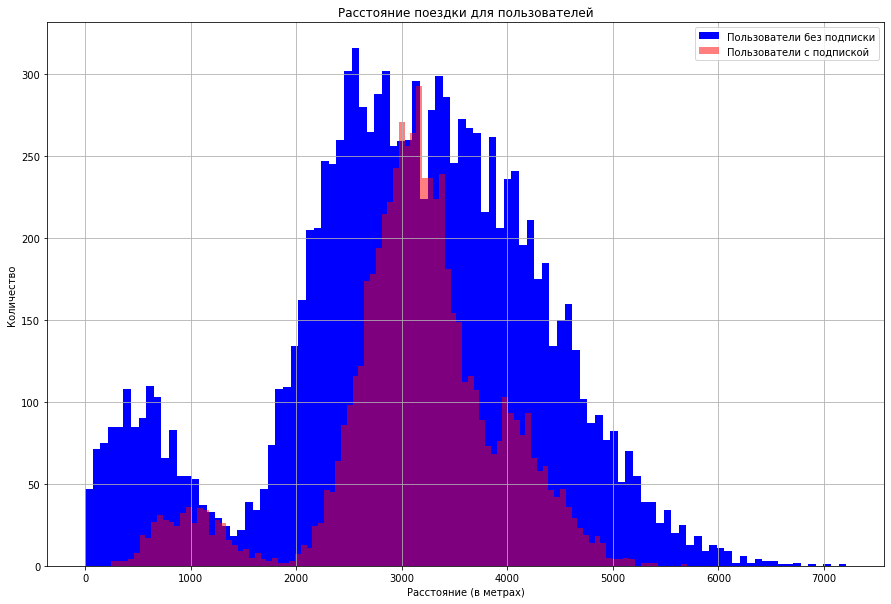

In [39]:
sub_free_data_plot = sub_free_data['distance'].plot(title='Расстояние поездки для пользователей',
                   x='distance', kind='hist', bins=100, color='blue', grid=True, figsize=(15,10))
sub_ultra_data_plot = sub_ultra_data['distance'].plot(title='Расстояние поездки для пользователей', 
                                kind='hist', bins=100, color='red', alpha=0.5,  grid=True, figsize=(15,10))
sub_free_data_plot.set_xlabel('Расстояние (в метрах)')
sub_free_data_plot.set_ylabel('Количество')
plt.legend(['Пользователи без подписки','Пользователи с подпиской'])
plt.show()

Из построенного графика можно говорить о том, что **наибольшая кучность** пользователей арендующих самокат обеих категорий наблюдается в диапазоне *от 2000 до 4500 метров*. Однако для пользователей с подпиской этот диапазон куда меньше - *от 2500 до 3500 метров*, явный пик - *3000 метров*. Также нельзя не отметить хоть и небольшой, но всё же рост графика в диапазоне *до 1000 метров*, в основном этот рост вызывают пользователи *без подписки*, пользователей *с подпиской* там существенно мало, так как в основном они арендуют самокат на дальние поездки. Это подтверждает предыдущие предположения, что в основном пользователи без подписки арендуют самокаты для поездок на близкие расстояния. 

##### Визуализируем информацию о времени поездок для пользователей без подписки и с подпиской

Для визуализации построим 2 гистограммы и отобразим на одном графике, воспользуемся функцией `.plot()`, куда в качестве значений для оси Х передадим столбец датафрейма `'duration'`, количество корзин `bins` установим равным `100`, для пользователей без подписки график будет синий, а с подпиской - красный, причем зададим ему прозрачность `alpha` `0.5`, чтобы лучше видеть совпадения графиков. Правильно  подпишем оси и выведем легенду графика.

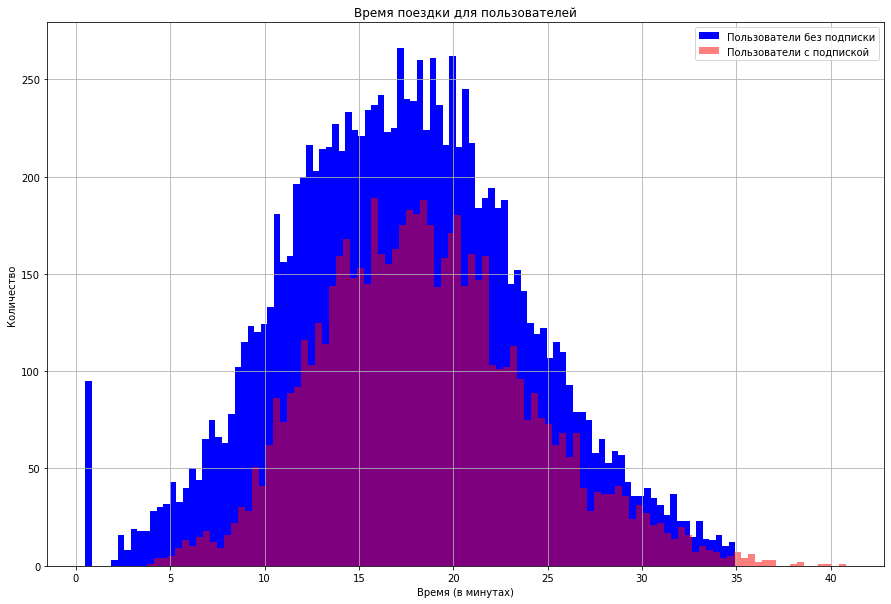

In [40]:
sub_free_data_time_plot = sub_free_data['duration'].plot(title='Время поездки для пользователей',
                   kind='hist', bins=100, color='blue', grid=True, figsize=(15,10))

sub_ultra_data_time_plot = sub_ultra_data['duration'].plot(title='Время поездки для пользователей',  
                                                           kind='hist', bins=100, color='red', alpha=0.5, grid=True, figsize=(15,10))
sub_ultra_data_time_plot.set_xlabel('Время (в минутах)')
sub_ultra_data_time_plot.set_ylabel('Количество')
plt.legend(['Пользователи без подписки','Пользователи с подпиской'])
plt.show()

Из графика гистограмм следует, что **наибольшая плотность данных** находится в диапазоне *от 10 до 25 минут* для пользователей обеих категорий. Следовательно, можно предположить, что наличие подписки никак не влияет на время аренды самоката. Графики гистограмм практически схожи, отличаются только высотой, что логично, учитывая что пользователей без подписки больше, чем с подпиской.

**Промежуточный вывод:**

В результате объединение данных и визуализации информации о пользователях обеих категорий получили следующее:
- объединили данные о пользователях, поездках и подписках в один датафрейм 
- создали два раздельных датафрейма c данными о пользователях без подписки и с подпиской
- из визуализации данных определили, что:
  *  время поездки никак не зависит от наличия у пользователя подписки, так как в основном у обеих категорий время составляет от 10 до 25 минут
  * именно пользователи без подписки создают горку в *пункте 3.4*, так как только они чаще всего арендуют самокат для поездки на близкое расстояние
  * у пользователей обеих категорий в основном поездки также на одно расстояние от 2000 до 4500 метров, но у пользователей с подпиской диапазон существенно сужается - от 2500 до 3500 метров


### Шаг 5. Подсчёт выручки

#### Создайте датафрейм с агрегированными данными о поездках на основе датафрейма с объединёнными данными из шага 4: найдите суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц.

Для дальнейшей работы создадим копию датафрейма `full_data` и сохраним скопированный датафрейм под названием `full_data_copy`.

In [41]:
full_data_copy = full_data.copy(deep=True)

In [42]:
full_data_copy.head()

,user_id,name,age,city,subscription_type,minute_price,start_ride_price,subscription_fee,distance,duration,date,month_ride
0,1,Кира,22,Тюмень,ultra,6,0,199,4409.919140,25.599769,2021-01-01,1
1,1,Кира,22,Тюмень,ultra,6,0,199,2617.592153,15.816871,2021-01-18,1
2,1,Кира,22,Тюмень,ultra,6,0,199,754.159807,6.232113,2021-04-20,4
3,1,Кира,22,Тюмень,ultra,6,0,199,2694.783254,18.511000,2021-08-11,8
4,1,Кира,22,Тюмень,ultra,6,0,199,4028.687306,26.265803,2021-08-28,8


Преобразуем столбец `'duration'` датафрейма `full_data_copy` путём округления в нём данных до целых чисел методом `apply` и использованием лямбды-функции, куда в качестве аргумента будем передавать значение в ячейки столбца, а в инструкции - округляем его в большую сторону путем метода `.ceil()`:

In [43]:
full_data_copy['duration'] = full_data_copy['duration'].astype(float)
full_data_copy['duration'] = full_data_copy['duration'].apply(lambda x: math.ceil(x))

Сформируем сводную таблицу `piv_tab`: зададим индексы - `index` - по которым будем группировать `'user_id'` и `'month_ride'`, значения `values` - `'distance'`,`'duration'`,`'subscription_type'`,`'minute_price'`,`'start_ride_price'`,`'subscription_fee'`, a `aggfunc` - `'sum'`,`'count'`,`'first'`. После этого выведем её на экран:

In [45]:
piv_tab = full_data_copy.pivot_table(index=['user_id','month_ride'], values=['distance','duration','subscription_type','minute_price','start_ride_price','subscription_fee'], 
                                    aggfunc=['sum','count','first'])
piv_tab

sum                                         \
                        distance duration minute_price start_ride_price   
user_id month_ride                                                        
1       1            7027.511294       42           12                0   
        4             754.159807        7            6                0   
        8            6723.470560       46           12                0   
        10           5809.911100       32           12                0   
        11           7003.499363       56           18                0   
...                          ...      ...          ...              ...   
1534    6            3409.468534       26           16              100   
        8            7622.453034       48           16              100   
        9            4928.173852       23            8               50   
        11          13350.015305       78           32              200   
        12           2371.711192       16            8               50   

                                       count                        \
                   subscription_fee distance duration minute_price   
user_id month_ride                                                   
1       1                       398        2        2            2   
        4                       199        1        1            1   
        8                       398        2        2            2   
        10                      398        2        2            2   
        11                      597        3        3            3   
...                             ...      ...      ...          ...   
1534    6                         0        2        2            2   
        8                         0        2        2            2   
        9                         0        1        1            1   
        11                        0        4        4            4   
        12                        0        1        1            1   

                                                                        \
                   start_ride_price subscription_fee subscription_type   
user_id month_ride                                                       
1       1                         2                2                 2   
        4                         1                1                 1   
        8                         2                2                 2   
        10                        2                2                 2   
        11                        3                3                 3   
...                             ...              ...               ...   
1534    6                         2                2                 2   
        8                         2                2                 2   
        9                         1                1                 1   
        11                        4                4                 4   
        12                        1                1                 1   

                          first                                         \
                       distance duration minute_price start_ride_price   
user_id month_ride                                                       
1       1           4409.919140       26            6                0   
        4            754.159807        7            6                0   
        8           2694.783254       19            6                0   
        10          2770.890808       17            6                0   
        11          2842.118050       24            6                0   
...                         ...      ...          ...              ...   
1534    6            195.447469        7            8               50   
        8           3644.708038       21            8               50   
        9           4928.173852       23            8               50   
        11          3781.098080       20            8               50  

Изменим названия столбцов сводной таблицы `piv_tab`: 

In [46]:
piv_tab.columns = (['sum_distance', 'sum_duration','1','2','3','month_count','4','5','6','7','8','distance','duration','minute_price','start_ride_price','subscription_fee','subscription_type'])

Проверим изменённые названия выводом на экран:

In [47]:
piv_tab.head()

sum_distance  sum_duration   1  2    3  month_count  4  5  \
user_id month_ride                                                              
1       1            7027.511294            42  12  0  398            2  2  2   
        4             754.159807             7   6  0  199            1  1  1   
        8            6723.470560            46  12  0  398            2  2  2   
        10           5809.911100            32  12  0  398            2  2  2   
        11           7003.499363            56  18  0  597            3  3  3   

                    6  7  8     distance  duration  minute_price  \
user_id month_ride                                                 
1       1           2  2  2  4409.919140        26             6   
        4           1  1  1   754.159807         7             6   
        8           2  2  2  2694.783254        19             6   
        10          2  2  2  2770.890808        17             6   
        11          3  3  3  2842.118050        24             6   

                    start_ride_price  subscription_fee subscription_type  
user_id month_ride                                                        
1       1                          0               199             ultra  
        4                          0               199             ultra  
        8                          0               199             ultra  
        10                         0               199             ultra  
        11                         0               199             ultra

Удалим столбцы в `piv_tab`, которые нам не нужны - то есть содержат дубликаты столбцов или не несут дальнейшей информативности для исследования: 

In [48]:
piv_tab = piv_tab.drop(['1','2','3','4','5','6','7','8','distance','duration'], axis=1)

Проверим изменения:

In [49]:
piv_tab.head()

sum_distance  sum_duration  month_count  minute_price  \
user_id month_ride                                                          
1       1            7027.511294            42            2             6   
        4             754.159807             7            1             6   
        8            6723.470560            46            2             6   
        10           5809.911100            32            2             6   
        11           7003.499363            56            3             6   

                    start_ride_price  subscription_fee subscription_type  
user_id month_ride                                                        
1       1                          0               199             ultra  
        4                          0               199             ultra  
        8                          0               199             ultra  
        10                         0               199             ultra  
        11                         0               199             ultra

Теперь создадим копию получившейся сводной таблицы `piv_tab` в переменную `aggregate_data`, с которой в дальнейшем и будем работать, так как там содержится актуальная и нужная информация:

In [50]:
aggregate_data = piv_tab.copy(deep=True)

Выведем первые строки для проверки правильности работы и вывода данных:

In [51]:
aggregate_data.head()

sum_distance  sum_duration  month_count  minute_price  \
user_id month_ride                                                          
1       1            7027.511294            42            2             6   
        4             754.159807             7            1             6   
        8            6723.470560            46            2             6   
        10           5809.911100            32            2             6   
        11           7003.499363            56            3             6   

                    start_ride_price  subscription_fee subscription_type  
user_id month_ride                                                        
1       1                          0               199             ultra  
        4                          0               199             ultra  
        8                          0               199             ultra  
        10                         0               199             ultra  
        11                         0               199             ultra

Данные отобразились правильно.

#### В этот же датафрейм добавьте столбец с помесячной выручкой, которую принёс каждый пользователь.

Для этого обратитесь к информации об условиях оплаты для подписчиков и тех, у кого нет подписки. Продолжительность каждой поездки в каждой строке исходного датафрейма для подсчёта стоимости округляется до следующего целого числа: например, значения 25.3, 25.5 и 26.0 должны быть преобразованы к  26.

Выведем ещё раз первые строки датафрейма:

In [52]:
aggregate_data.head()

sum_distance  sum_duration  month_count  minute_price  \
user_id month_ride                                                          
1       1            7027.511294            42            2             6   
        4             754.159807             7            1             6   
        8            6723.470560            46            2             6   
        10           5809.911100            32            2             6   
        11           7003.499363            56            3             6   

                    start_ride_price  subscription_fee subscription_type  
user_id month_ride                                                        
1       1                          0               199             ultra  
        4                          0               199             ultra  
        8                          0               199             ultra  
        10                         0               199             ultra  
        11                         0               199             ultra

Для нахождения месячной выручки с пользователя, согласно тем данным, которые нам передал сервис аренды самокатов GoFast, рассчитаем сумму полученную компанией за месяц и запишем в новый столбец `'month_income'` датафрейма `aggregate_data`, то есть суммарное время (в минутах) - данные столбца `'sum_duration'` - умножим на цену 1 минуты - данные столбца `'minute_price'` - согласно плану и сложим со стоимостью старта (начала поездки) - данные столбца `'start_ride_price'` - умноженного на количество совершенных поездок `'month_count'` и абонентской платой (для пользователей с подпиской) - данные столбца `'subscription_fee'`. Так как ранее мы уже округлили суммарное время до целых чисел, то делать это ещё раз нет необходимости: 

In [53]:
aggregate_data['month_income'] = (aggregate_data['minute_price'] * aggregate_data['sum_duration'] + 
                                  aggregate_data['start_ride_price'] * aggregate_data['month_count'] + aggregate_data['subscription_fee'])

Выведем первые строки, чтобы удостоверится в правильности данных датафрейма:

In [54]:
aggregate_data.head()

sum_distance  sum_duration  month_count  minute_price  \
user_id month_ride                                                          
1       1            7027.511294            42            2             6   
        4             754.159807             7            1             6   
        8            6723.470560            46            2             6   
        10           5809.911100            32            2             6   
        11           7003.499363            56            3             6   

                    start_ride_price  subscription_fee subscription_type  \
user_id month_ride                                                         
1       1                          0               199             ultra   
        4                          0               199             ultra   
        8                          0               199             ultra   
        10                         0               199             ultra   
        11                         0               199             ultra   

                    month_income  
user_id month_ride                
1       1                    451  
        4                    241  
        8                    475  
        10                   391  
        11                   535

Из полученного датафрейма можно говорить о том, что информация в него была записана корректно.

В таком виде можно легко работать с датафреймом и искать информацию о пользователе с определённым ID.

### Шаг 6. Проверка гипотез

Продакт-менеджеры сервиса хотят увеличить количество пользователей с подпиской. Для этого они будут проводить различные акции, но сначала нужно выяснить несколько важных моментов.

#### Важно понять, тратят ли пользователи с подпиской больше времени на поездки? Если да, то пользователи с подпиской могут быть «выгоднее» для компании. Проверьте гипотезу. Используйте исходные данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.

Для проверки этой гипотезы воспользуемся односторонней гипотезой о равенстве средних двух генеральных совокупностей. Для этого в специальный метод `scipy.stats.ttest_ind()` передадим в качестве параметров: `ultra_time` и `free_time` - наборы значений времени пользователей с подпиской и без подписки соответственно, которые содержат выборки, `alternative` — текстовый параметр, задающий альтернативную гипотезу примем равным `'greater'`. То есть аргумент `'greater'` будет обозначать и проверять следующую альтернативную гипотезу - *«Среднее значение первой генеральной совокупности больше среднего значения второй генеральной совокупности»*.

**Сформулируем гипотезы:**

*Н0(Нулевая гипотеза):* Среднее генеральной совокупности времени пользователей с подпиской и без подписки равно.

*Н1(Альтернативная гипотеза):* Среднее значение генеральной совокупности времени пользователей с подпиской больше среднего значения генеральной совокупности времени пользователей без подписки.

Проверим сформулированные гипотезы.

In [55]:
alpha = 0.05 # уровень статистической значимости

ultra_time = sub_ultra_data['duration']
free_time = sub_free_data['duration']

results = st.ttest_ind(ultra_time, free_time, alternative='greater')

print('p-значение:', results.pvalue)

if (results.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу') 

p-значение: 1.2804098316645618e-34
Отвергаем нулевую гипотезу


После проверки гипотезы можно наблюдать, что принимается альтернативная гипотеза, то есть *среднее значение первой генеральной совокупности больше среднего значения второй генеральной совокупности*. Ранее это можно было предположить, исходя из того, что раз пользователь купил подписку, то он *может* часто арендовывать самокат и долго его использовать. Теперь же мы проверили данную гипотезу на реальных данных, *подтвердили* её и можем говорить, что это так.  

#### Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? Проверьте гипотезу и сделайте выводы.

Для проверки этой гипотезы воспользуемся односторонней гипотезой о равенстве средних двух генеральных совокупностей. Для этого в специальный метод `scipy.stats.ttest_1samp()` передадим в качестве параметров: `ultra_dist` -  набор данных о расстоянии одной поездки для пользователей с подпиской, `popmean` - предполагаемое среднее , `alternative` — текстовый параметр, задающий альтернативную гипотезу примем равным `'greater'`. То есть аргумент `'greater'` будет обозначать и проверять следующую альтернативную гипотезу - *«Cреднее расстояние одной поездки у подписчиков больше, чем 3130 метров.»*.

**Сформулируем гипотезы:**

*Н0(Нулевая гипотеза):* Среднее значение генеральной совокупности данных о расстоянии одной поездки для пользователей с подпиской равно значению 3130.

*Н1(Альтернативная гипотеза):* Среднее значение генеральной совокупности данных о расстоянии одной поездки для пользователей с подпиской больше значения 3130.

Проверим сформулированные гипотезы.

In [56]:
popmean = 3130

In [57]:
alpha = 0.05 # уровень статистической значимости
ultra_dist = sub_ultra_data['distance']

results = st.ttest_1samp(ultra_dist, popmean, alternative='greater')

print('p-значение:', results.pvalue)

if (results.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу') 

p-значение: 0.9195368847849785
Не отвергаем нулевую гипотезу


После проверки гипотезы можно наблюдать, что принимается нулевая гипотеза, то есть *среднее расстояние одной поездки у пользователей с подпиской равно 3130 метров*. Эта гипотеза также может быть подкреплена подтверждением из графика **пункта 4.3.1**, в том пункте мы только предположили возможный разброс расстояний, который был весьма большим, а в этом пункте мы приблизились к среднему значению одной поездки пользователя с подпиской. 

Из проверенных гипотез, можно говорить, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров.

#### Проверьте гипотезу о том, будет ли помесячная выручка от пользователей с подпиской по месяцам выше, чем выручка от пользователей без подписки. Сделайте вывод.

Для проверки этой гипотезы также воспользуемся односторонней гипотезой о равенстве средних двух генеральных совокупностей. Для этого в метод `scipy.stats.ttest_ind()` передадим в качестве параметров: `ultra_income` и `free_income` - наборы значений выручки по месяцам пользователей с подпиской и без подписки соответственно, которые содержат выборки, `alternative` — текстовый параметр, задающий альтернативную гипотезу примем равным `'greater'`. То есть аргумент `'greater'` будет обозначать и проверять следующую альтернативную гипотезу - *«Среднее значение первой генеральной совокупности больше среднего значения второй генеральной совокупности»*.

**Сформулируем гипотезы:**

*Н0(Нулевая гипотеза):* Среднее значение генеральной совокупности выручки по месяцам пользователей с подпиской и без подписки равно.

*Н1(Альтернативная гипотеза):* Среднее значение генеральной совокупности выручки по месяцам пользователей с подпиской больше среднего значения генеральной совокупности выручки по месяцам пользователей без подписки.

Проверим сформулированные гипотезы.

In [58]:
alpha = 0.05 # уровень статистической значимости

ultra_income = aggregate_data.query('subscription_type == "ultra"')
free_income = aggregate_data.query('subscription_type == "free"')

results = st.ttest_ind(ultra_income['month_income'], free_income['month_income'], alternative='greater')

print('p-значение:', results.pvalue)

if (results.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не отвергаем нулевую гипотезу') 

p-значение: 1.8850394384715216e-31
Отвергаем нулевую гипотезу


После проверки гипотезы можно наблюдать, что принимается альтернативная гипотеза, то есть *среднее значение первой генеральной совокупности больше среднего значения второй генеральной совокупности*. Логично было бы предположить, что да, так как раз пользователь купил подписку, то он уже потратил деньги на её покупку, в то время как другой клиент сервиса может пользоваться бесплатно, но со стоимостью минут чуть выше. Сейчас же мы проверили данную гипотезу на реальных данных, *подтвердили* её и можем с уверенностью говорить, что это так.  

Таким образом, можно говорить о том, что помесячная выручка от пользователей с подпиской больше, чем помесячная выручка от пользователей без подписки. 

#### Представьте такую ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?

Я предполагаю, что будет необходима проверка гипотезы о равенстве средних для зависимых выборок. Если брать выборки из данных, то они будут зависимыми, то есть это будет количество обращений пользователей до и после обновления сервера. К примеру были получены разные обращения от пользователя, однако пользователь один и тот же, он никак не изменился, когда писал обращения, изменилась ситуация(сервер до и после обновления) во время которой он отправлял обращения; поэтому эта ситуация и будет зависимой. Для проверки гипотезы нужно будет использовать метод `scipy.stats.ttest_rel()`, в который передадим два параметра: наборы данных до и после и стоит отметить, что оба набора должны быть одинаковыми по размеру.

### Шаг 7. Распределения

**7.1 Отделу маркетинга GoFast поставили задачу: нужно провести акцию с раздачей промокодов на один бесплатный месяц подписки, в рамках которой как минимум 100 существующих клиентов должны продлить эту подписку. То есть по завершении периода действия подписки пользователь может либо отказаться от неё, либо продлить, совершив соответствующий платёж.**

Эта акция уже проводилась ранее и по итогу выяснилось, что после бесплатного пробного периода подписку продлевают 10 % пользователей. Выясните, какое минимальное количество промокодов нужно разослать, чтобы вероятность не выполнить план была примерно 5 %. Подберите параметры распределения, описывающего эту ситуацию, постройте график распределения и сформулируйте ответ на вопрос о количестве промокодов.



**7.2 Отдел маркетинга рассылает клиентам push-уведомления в мобильном приложении. Клиенты могут открыть его или не открывать. Известно, что уведомления открывают около 40 % получивших клиентов. Отдел планирует разослать 1 млн уведомлений. С помощью аппроксимации постройте примерный график распределения и оцените вероятность того, что уведомление откроют не более 399,5 тыс. пользователей.**

В рамках поставленной задачи удобнее воспользоваться аппроксимацией биномиального распределения нормальным. Выполним следующие шаги: зададим необходимые параметры для распределения, определим мат.ожидание и ст.отклонение и найдём интересующую нас вероятность с помощью метода `.cdf()`.

In [59]:
# задаём параметры биномиального распределения
n = 1e+6 
p = 0.4 

# зададим мат.ожидание и ст.отклонение нормального распределения равными
# мат.ожиданию и ст.отклонению биномиального распределения
mu = n * p
sigma = sqrt(n * p * (1 - p))

# зададим нормальное распределение
distr = st.norm(mu, sigma)  

# найдём вероятность
result = distr.cdf(399500) 
print('Bероятность того, что уведомление откроют не более 399,5 тыс. пользователей:', round(result*100,3),'%')

Bероятность того, что уведомление откроют не более 399,5 тыс. пользователей: 15.372 %


Из полученных результатов видно, что вероятность того, что менее 399,5 тысяч клиентов откроют уведомление, около 15%, что достаточно мало. Скорее всего любопытство клиента пересилит его, и он откроет уведомление.

Теперь попытаемся построить примерный график распределения:

In [60]:
# зададим функцию - понадобится для визуализации нормального распределения - которая выдаёт <num> чисел,
# равномерно распределённых от <start> до <stop>
def linspace(start, stop, num):
    step = (stop - start) / (num - 1)
    result = []
    for i in range(num):
        result.append(start + step * i)
    return result

In [61]:
# границы промежутка, в котором будем строить аппроксимацию -
# от n*p минус 4 ст.отклонения бином.распределения
# до n*p плюс 4 ст.отклонения бином.распределения
left = int(n * p - 4 * sqrt(n * p * (1 - p)))
right = int(n * p + 4 * sqrt(n * p * (1 - p)))

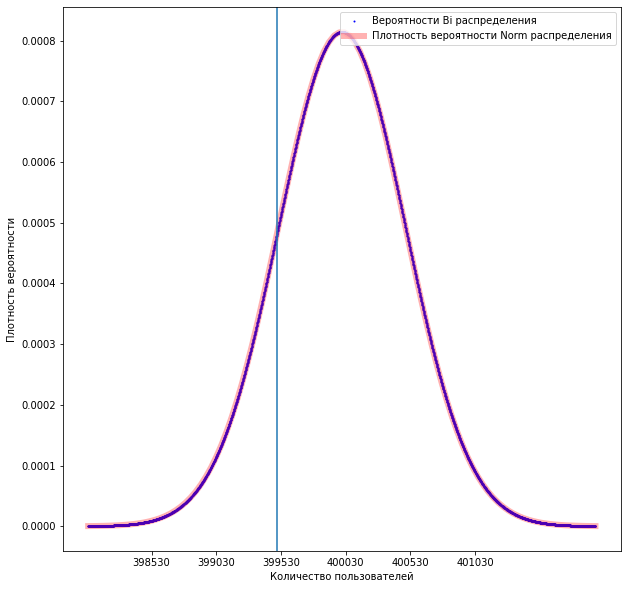

In [62]:
# зададим набор значений биномиальной величины на выбранном промежутке:
x = list(range(max(0, left), right))
# задаём размеры графика
plt.figure(figsize=(10,10))
# рисуем график биномиального распределения
ax = plt.subplot()
ax.plot(x, binom.pmf(x, n, p), 'bo', ms=1, label='Вероятности Bi распределения')

# рисуем график нормального распределения:
x = linspace(left, right, 100)
ax.plot(x, norm.pdf(x, mu, sigma), 'r-', lw=6, alpha=0.3, label='Плотность вероятности Norm распределения')

# рисуем вертикальную прямую в значении х = 399,5 тыс
plt.axvline(x=399500)
 
# зададим подписи по оси x в пределах ± 3 ст.отклонений от мат.ожидания c интервалом 500
x_ticks = list(range(int(mu - 3 * sigma), int(mu + 3 * sigma), 500))
ax.set_xticks(x_ticks)

# настраиваем расположение легенды и выводим график
ax.legend(loc='upper right')
ax.set_xlabel('Количество пользователей')
ax.set_ylabel('Плотность вероятности')
plt.show()

In [63]:
# выводим, выполняется ли условие аппроксимации:
# лежит ли mu ± 3 sigma в промежутке от 0 до n:
if (mu - (3 * sigma) >= 0) and ((mu + (3 * sigma) <= n)):
    print('Условие аппроксимации выполняется')
else:
    print('Условие аппроксимации не выполняется')

Условие аппроксимации выполняется


 ### Общий вывод

В результате проведенного исследования были получены следующие результаты:
- Проверили и избавили исходные данные от пропусков и дубликатов
- Объединили данные о пользователях, поездках и подписках в один датафрейм 
- Создали два раздельных датафрейма c данными о пользователях без подписки и с подпиской
- Были построены и проанализированы гистограммы
- Города, в которых чаще всего арендуют самокаты - Пятигорск и Екатеринбург, и меньше всего - Москва
- Больше половины пользователей (54.43%) не пользуются, а 45.57% - наоборот пользуются подпиской при аренде самокатов
- Молодые люди от 20 до 30 лет чаще всего являются пользователями аренды самокатов, наиболее частые - пользователи 25 лет
- Наиболее частая продолжительность поездок пользователей от 10 до 25 минут
- Время поездки никак **не зависит** от наличия у пользователя *подписки*
- Наиболее часто именно *пользователи без подписки* арендуют самокаты для поездок на близкие расстояния (до 1 км)
- У *пользователей обеих категорий* в основном поездки также на одно расстояние от 2000 до 4500 метров, у *пользователей с подпиской* диапазон уже - от 2500 до 3500 метров, явный пик - 3000 метров. 
- Проверена и подтверждена гипотеза, что пользователи с подпиской тратят *больше* времени на поездки
- Проверена и доказана гипотеза, что среднее расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров
- Проверена и подтверждена гипотеза, что помесячная выручка от пользователей с подпиской по месяцам *выше*, чем выручка от пользователей без подписки. 
- Предположили, какая бы гипотеза понадобилась для проверки данных о количестве обращений, в случае если техническая команда сервиса решила бы обновить сервера мобильного приложения 


Из представленных выводов можно сказать следующее: более "выгодными" для сервиса аренды самокатов являются пользователи с подпиской, так как несмотря на то, что их чуть меньше половины (45.57%), они:
1. тратят больше времени на поездки, следовательно, чем больше времени на поездки, тем больше выручка с пользователя 
2. помимо платы за поездки, также платят месячную подписку - 199 руб
3. с учётом меньшего тарифного плана - 6 руб/мин - приносят месячную выручку больше, чем пользователи без подписки с планом - 8 руб/мин